# Reddit-Diskursdaten – Explorative Analyse

Struktur-Analyse der geflachten Thread-Datei (`conversation_threads_flat.ndjson`)
für das HoreKa-Labeling-Projekt.

Dieses Notebook läuft **lokal** (nicht auf HoreKa) und erwartet die Daten unter
`../data/` relativ zum Notebook-Ordner.

**Inhalt**
1. Laden & Grundzahlen
2. Felder & Datenqualität
3. Thread-Struktur (Größe, Tiefe)
4. Textlängen (Wörter/Zeichen)
5. Parent-Verfügbarkeit (relevant fürs Labeling)
6. Subreddits & Themen
7. Aktivität über Zeit
8. Nutzer & Bots
9. Kompakte Zusammenfassung


## 0. Setup

In [1]:
import json
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
# Daten liegen relativ zum Notebook unter ../data/
DATA_DIR = Path("../data")
FILENAME = "conversation_threads_flat.ndjson"
DATA_PATH = DATA_DIR / FILENAME

assert DATA_PATH.exists(), (
    f"Datei nicht gefunden: {DATA_PATH.resolve()}\n"
    f"Erwartet wird sie unter ../data/ relativ zum Notebook."
)
print("Lese:", DATA_PATH.resolve())
print("Größe:", f"{DATA_PATH.stat().st_size/1e6:.1f} MB")

Lese: /Users/arthur/DataspellProjects/reddit-l/data/conversation_threads_flat.ndjson
Größe: 148.0 MB


## 1. Laden & Grundzahlen

lesen der NDJSON zeilenweise ein (robust gegen einzelne kaputte Zeilen)
und legen sie in einen DataFrame.

In [3]:
records = []
bad = 0
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            bad += 1

df = pd.DataFrame(records)
print(f"Geladen: {len(df):,} Kommentare")
print(f"Kaputte Zeilen übersprungen: {bad}")
print(f"Spalten: {len(df.columns)}")
df.head(3)

Geladen: 119,405 Kommentare
Kaputte Zeilen übersprungen: 0
Spalten: 23


,thread_id,submission_id,root_id,comment_id,parent_id,link_id,body,user,score,created_utc,permalink,subreddit,depth,submission_title,submission_selftext,submission_author,submission_score,submission_created_utc,submission_subreddit,submission_url,best_topic_index,best_topic_similarity,ancestor_path
0,1dcign3,1dcign3,l7xzn6o,l7xzn6o,1dcign3,1dcign3,^^^^AUTOMOD ***Thanks for posting! This comme...,AutoModerator,2,1718016034,/r/AmItheAsshole/comments/1dcign3/wibta_for_wa...,AmItheAsshole,0,WIBTA for warning the Airbnb about the huge pa...,I live in a tiny rural town. My friend from Re...,DemNodules,None,1718016033000,AmItheAsshole,None,1,0.60075,[]
1,1dcign3,1dcign3,l7y0nvq,l7y0nvq,1dcign3,1dcign3,Welcome to /r/AmITheAsshole. Please view our [...,Judgement_Bot_AITA,1,1718016661,/r/AmItheAsshole/comments/1dcign3/wibta_for_wa...,AmItheAsshole,0,WIBTA for warning the Airbnb about the huge pa...,I live in a tiny rural town. My friend from Re...,DemNodules,None,1718016033000,AmItheAsshole,None,1,0.60075,[]
2,1dcign3,1dcign3,l7y1uom,l7y1uom,1dcign3,1dcign3,"If you narc on me for having a catered dinner,...",YouthNAsia63,-2,1718017368,/r/AmItheAsshole/comments/1dcign3/wibta_for_wa...,AmItheAsshole,0,WIBTA for warning the Airbnb about the huge pa...,I live in a tiny rural town. My friend from Re...,DemNodules,None,1718016033000,AmItheAsshole,None,1,0.60075,[]


In [4]:
# Grundzahlen auf einen Blick
n_comments = len(df)
n_threads = df["thread_id"].nunique() if "thread_id" in df else None
n_users = df["user"].nunique() if "user" in df else None
n_subs = df["subreddit"].nunique() if "subreddit" in df else None

print(f"Kommentare gesamt : {n_comments:,}")
print(f"Threads           : {n_threads:,}")
print(f"Eindeutige Nutzer : {n_users:,}")
print(f"Subreddits        : {n_subs}")
if n_threads:
    print(f"Ø Kommentare/Thread: {n_comments/n_threads:.1f}")

Kommentare gesamt : 119,405
Threads           : 988
Eindeutige Nutzer : 45,482
Subreddits        : 9
Ø Kommentare/Thread: 120.9


## 2. Felder & Datenqualität

Welche Spalten gibt es, welche Typen, und wie viel fehlt?

In [5]:
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean()*100).round(1),
    "n_unique": [df[c].nunique() for c in df.columns],
})
info.sort_values("pct_missing", ascending=False)

,dtype,n_missing,pct_missing,n_unique
submission_url,object,119405,100.0,0
submission_score,object,119405,100.0,0
thread_id,object,0,0.0,988
depth,int64,0,0.0,87
best_topic_similarity,float64,0,0.0,981
best_topic_index,int64,0,0.0,19
submission_subreddit,object,0,0.0,9
submission_created_utc,int64,0,0.0,988
submission_author,object,0,0.0,848
submission_selftext,object,0,0.0,113


## 3. Thread-Struktur

Wie groß sind die Threads, und wie tief verschachtelt? Die `depth` gibt die
Ebene an (0 = Top-Level-Kommentar direkt am Post).

In [6]:
thread_sizes = df.groupby("thread_id").size()
print("Thread-Größen (Kommentare pro Thread):")
print(thread_sizes.describe().round(1))
print()
print(f"Größter Thread: {thread_sizes.max():,} Kommentare")
print(f"Threads mit nur 1 Kommentar: {(thread_sizes==1).sum():,}")

Thread-Größen (Kommentare pro Thread):
count     988.0
mean      120.9
std       338.4
min         4.0
25%        15.0
50%        26.0
75%        83.2
max      6282.0
dtype: float64

Größter Thread: 6,282 Kommentare
Threads mit nur 1 Kommentar: 0


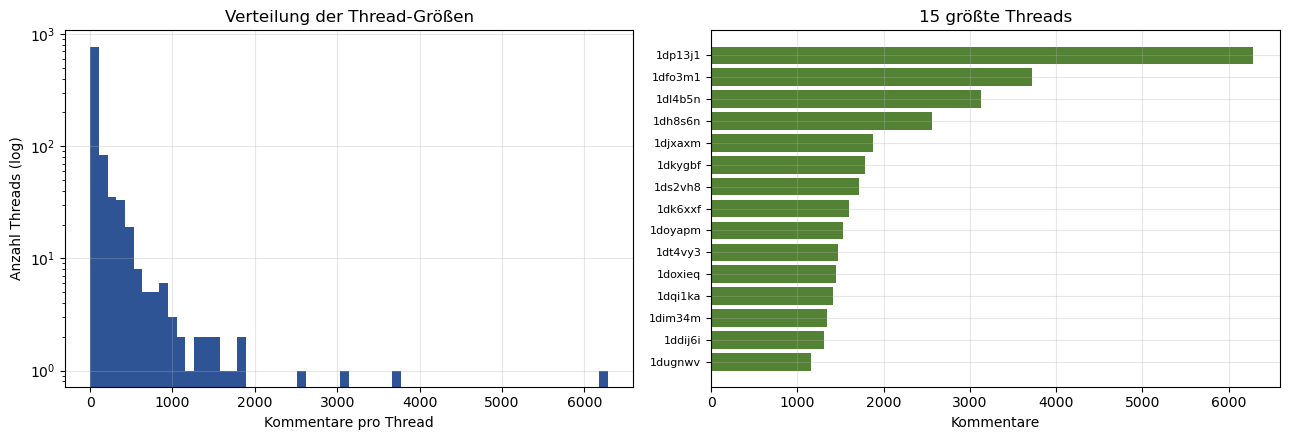

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Verteilung der Thread-Größen (log-y, weil stark schief)
axes[0].hist(thread_sizes, bins=60, color="#2E5496")
axes[0].set_yscale("log")
axes[0].set_title("Verteilung der Thread-Größen")
axes[0].set_xlabel("Kommentare pro Thread")
axes[0].set_ylabel("Anzahl Threads (log)")

# Top 15 größte Threads
top = thread_sizes.sort_values(ascending=False).head(15)
axes[1].barh(range(len(top)), top.values, color="#548235")
axes[1].set_yticks(range(len(top)))
axes[1].set_yticklabels([str(t)[:12] for t in top.index], fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title("15 größte Threads")
axes[1].set_xlabel("Kommentare")
plt.tight_layout(); plt.show()

Kommentare je Tiefe:
depth
0     37629
1     21130
2     16971
3     12530
4      9491
      ...  
82        1
83        1
84        1
85        1
86        1
Name: count, Length: 87, dtype: int64


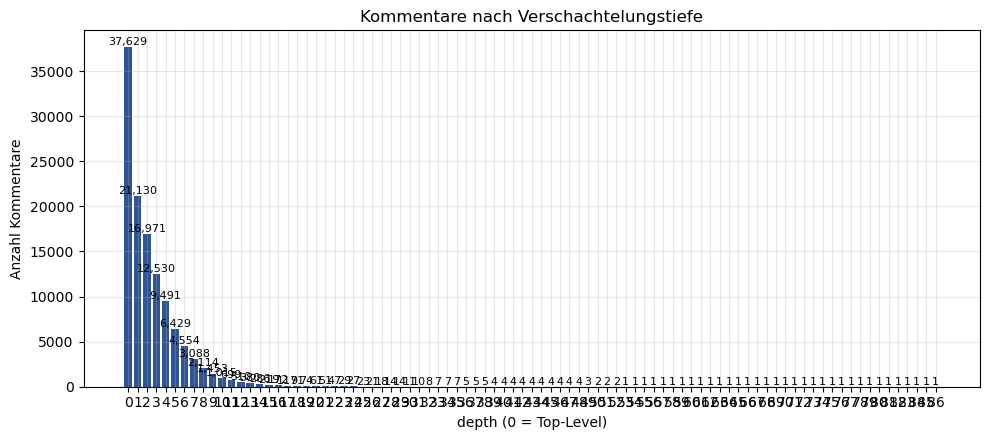


Anteil Top-Level (depth=0): 31.5%
Maximale Tiefe: 86


In [8]:
# Tiefenverteilung
if "depth" in df.columns:
    depth_counts = df["depth"].value_counts().sort_index()
    print("Kommentare je Tiefe:")
    print(depth_counts)

    fig, ax = plt.subplots()
    ax.bar(depth_counts.index.astype(str), depth_counts.values, color="#2E5496")
    ax.set_title("Kommentare nach Verschachtelungstiefe")
    ax.set_xlabel("depth (0 = Top-Level)")
    ax.set_ylabel("Anzahl Kommentare")
    for i, v in enumerate(depth_counts.values):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); plt.show()

    print(f"\nAnteil Top-Level (depth=0): {(df['depth']==0).mean()*100:.1f}%")
    print(f"Maximale Tiefe: {df['depth'].max()}")

## 4. Textlängen

Wie lang sind die Kommentare? Das ist direkt relevant fürs Labeling – sehr
kurze Kommentare ("lol", "This.") tragen wenig Diskurs-Signal.

In [9]:
body = df["body"].fillna("").astype(str)
df["n_chars"] = body.str.len()
df["n_words"] = body.str.split().apply(len)

print("Zeichen pro Kommentar:")
print(df["n_chars"].describe().round(1))
print("\nWörter pro Kommentar:")
print(df["n_words"].describe().round(1))

Zeichen pro Kommentar:
count    119405.0
mean        212.3
std         345.4
min           1.0
25%          41.0
50%         107.0
75%         244.0
max        9235.0
Name: n_chars, dtype: float64

Wörter pro Kommentar:
count    119405.0
mean         36.2
std          57.5
min           1.0
25%           7.0
50%          19.0
75%          42.0
max        1502.0
Name: n_words, dtype: float64


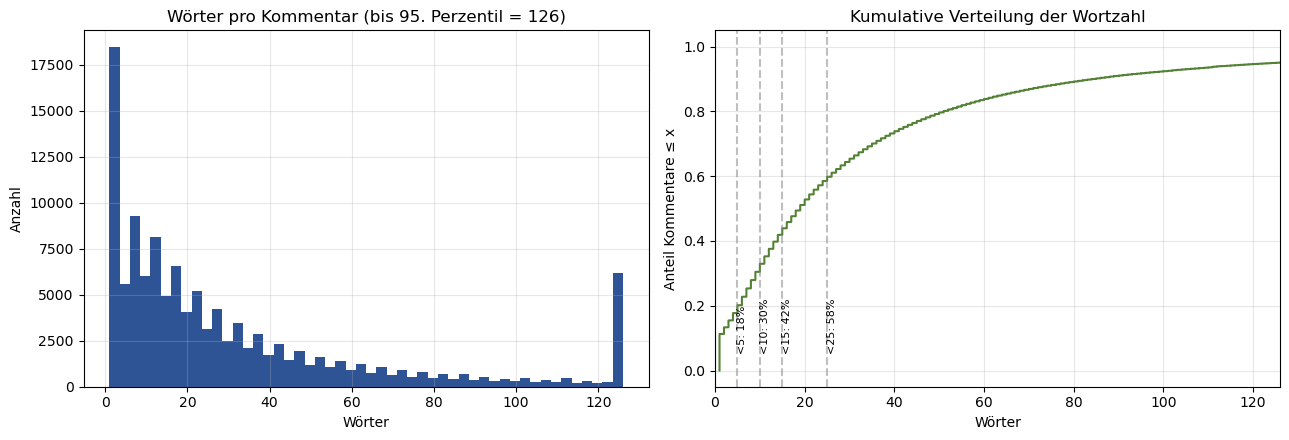

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Wörter (bis 95. Perzentil, sonst zerdrückt der Long Tail alles)
cap = int(df["n_words"].quantile(0.95))
axes[0].hist(df["n_words"].clip(upper=cap), bins=50, color="#2E5496")
axes[0].set_title(f"Wörter pro Kommentar (bis 95. Perzentil = {cap})")
axes[0].set_xlabel("Wörter"); axes[0].set_ylabel("Anzahl")

# Kumulative Verteilung mit Schwellen-Markierungen
sorted_w = np.sort(df["n_words"])
cum = np.arange(1, len(sorted_w)+1) / len(sorted_w)
axes[1].plot(sorted_w, cum, color="#548235")
axes[1].set_xlim(0, cap)
axes[1].set_title("Kumulative Verteilung der Wortzahl")
axes[1].set_xlabel("Wörter"); axes[1].set_ylabel("Anteil Kommentare ≤ x")
for thr in [5, 10, 15, 25]:
    frac = (df["n_words"] < thr).mean()
    axes[1].axvline(thr, color="gray", ls="--", alpha=0.5)
    axes[1].text(thr, 0.05, f"<{thr}: {frac*100:.0f}%", rotation=90,
                 fontsize=8, va="bottom")
plt.tight_layout(); plt.show()

In [11]:
# Wie viele Kommentare fallen unter typische Mindestlängen?
print("Anteil Kommentare unter Wort-Schwelle:")
for thr in [3, 5, 10, 15, 20, 25]:
    frac = (df["n_words"] < thr).mean()
    print(f"  < {thr:2d} Wörter: {frac*100:5.1f}%  ({(df['n_words']<thr).sum():,} Kommentare)")

Anteil Kommentare unter Wort-Schwelle:
  <  3 Wörter:  13.3%  (15,903 Kommentare)
  <  5 Wörter:  17.7%  (21,158 Kommentare)
  < 10 Wörter:  30.5%  (36,360 Kommentare)
  < 15 Wörter:  41.9%  (49,989 Kommentare)
  < 20 Wörter:  51.1%  (60,996 Kommentare)
  < 25 Wörter:  58.5%  (69,825 Kommentare)


## 5. Parent-Verfügbarkeit (fürs Labeling entscheidend)

Für die Dimensionen `responsiveness` und `agreement` braucht jeder Kommentar
den Text seines Eltern-Kommentars. Ein Kommentar ist auflösbar, wenn seine
`parent_id` als `comment_id` eines anderen Kommentars im Datensatz vorkommt.
Hängt er direkt am Post (`parent_id == link_id`), gibt es keinen Eltern-*Kommentar*.

In [12]:
comment_ids = set(df["comment_id"])

def parent_status(row):
    pid = row.get("parent_id")
    lid = row.get("link_id")
    if pid is None:
        return "kein_parent_feld"
    if pid == lid:
        return "top_level_post"      # hängt am Post
    if pid in comment_ids:
        return "parent_im_datensatz"  # auflösbar
    return "parent_fehlt"             # Eltern-Kommentar nicht im Sample

status = df.apply(parent_status, axis=1)
sc = status.value_counts()
print("Parent-Status:")
for k, v in sc.items():
    print(f"  {k:22} {v:>8,}  ({v/len(df)*100:.1f}%)")

resolvable = sc.get("parent_im_datensatz", 0)
print(f"\n=> {resolvable:,} Kommentare ({resolvable/len(df)*100:.1f}%) "
      f"können einen Eltern-Text bekommen.")

Parent-Status:
  parent_im_datensatz      81,776  (68.5%)
  top_level_post           37,502  (31.4%)
  parent_fehlt                127  (0.1%)

=> 81,776 Kommentare (68.5%) können einen Eltern-Text bekommen.


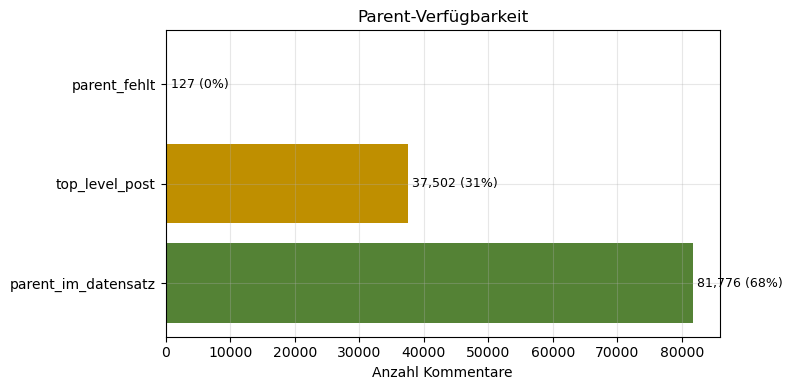

In [13]:
fig, ax = plt.subplots(figsize=(8,4))
colors = {"parent_im_datensatz":"#548235","top_level_post":"#BF8F00",
          "parent_fehlt":"#A61C00","kein_parent_feld":"#808080"}
bars = [(k, sc.get(k,0)) for k in ["parent_im_datensatz","top_level_post","parent_fehlt","kein_parent_feld"] if sc.get(k,0)>0]
ax.barh([b[0] for b in bars], [b[1] for b in bars],
        color=[colors[b[0]] for b in bars])
ax.set_title("Parent-Verfügbarkeit")
ax.set_xlabel("Anzahl Kommentare")
for i,(k,v) in enumerate(bars):
    ax.text(v, i, f" {v:,} ({v/len(df)*100:.0f}%)", va="center", fontsize=9)
plt.tight_layout(); plt.show()

## 6. Subreddits & Themen

Kommentare je Subreddit:
subreddit
worldnews              65147
AskReddit              26207
changemyview           13640
Conservative            5957
AmItheAsshole           3052
moderatepolitics        2789
PoliticalDiscussion     2133
Liberal                  335
TrueReddit               145
Name: count, dtype: int64


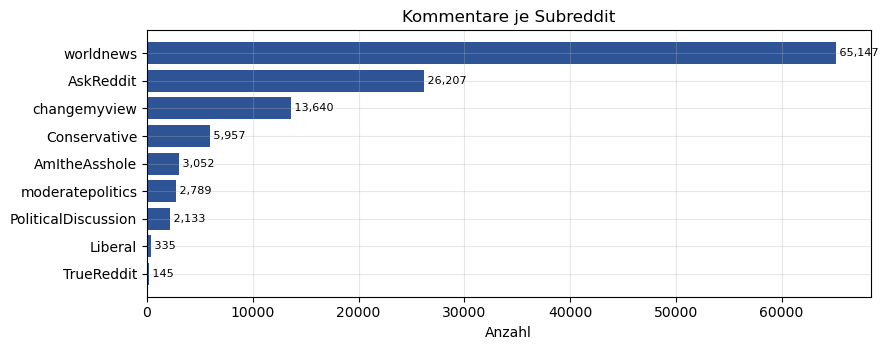

In [14]:
if "subreddit" in df.columns:
    sub_counts = df["subreddit"].value_counts()
    print("Kommentare je Subreddit:")
    print(sub_counts)

    fig, ax = plt.subplots(figsize=(9, max(3, len(sub_counts)*0.4)))
    ax.barh(range(len(sub_counts)), sub_counts.values, color="#2E5496")
    ax.set_yticks(range(len(sub_counts)))
    ax.set_yticklabels(sub_counts.index)
    ax.invert_yaxis()
    ax.set_title("Kommentare je Subreddit")
    ax.set_xlabel("Anzahl")
    for i, v in enumerate(sub_counts.values):
        ax.text(v, i, f" {v:,}", va="center", fontsize=8)
    plt.tight_layout(); plt.show()

In [15]:
# Falls ein Topic-Feld existiert (best_topic_index), dessen Verteilung zeigen
topic_col = next((c for c in ["best_topic_index","topic","best_topic"] if c in df.columns), None)
if topic_col:
    print(f"Themen-Feld gefunden: {topic_col}")
    print(df[topic_col].value_counts().sort_index())
else:
    print("Kein Themen-Feld gefunden.")

Themen-Feld gefunden: best_topic_index
best_topic_index
0      1939
1      4164
2       581
3     60527
4      8518
5      8338
6      2761
7       253
8      2194
9      2576
10     3771
11      208
12     1016
13     2189
14     5432
15     4011
16      802
17     4628
18     5497
Name: count, dtype: int64


## 7. Aktivität über Zeit

Aus `created_utc` (Unix-Zeit) rekonstruieren wir, wann die Kommentare entstanden.

Zeitstempel gültig: 119,405 / 119,405
Zeitraum: 2024-06-10 00:40:00  bis  2024-07-04 23:59:19


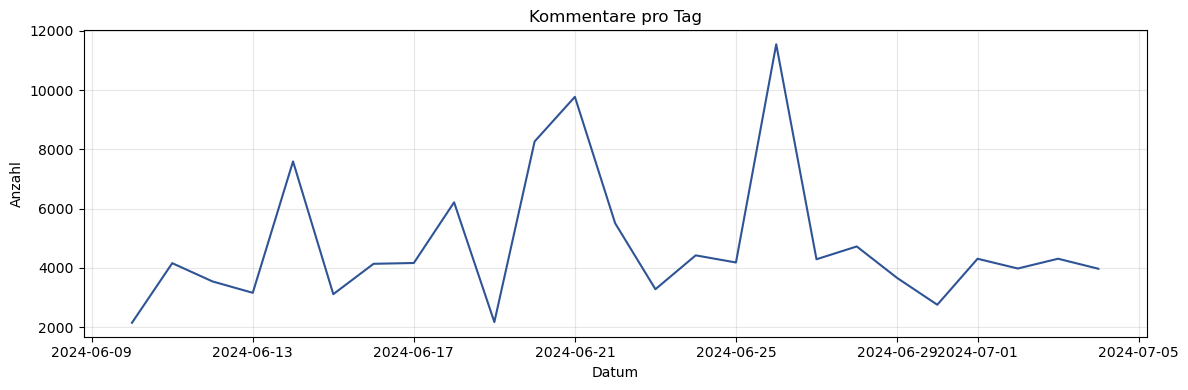

In [16]:
time_col = next((c for c in ["created_utc","created","timestamp"] if c in df.columns), None)
if time_col:
    # created_utc kann in Sekunden oder Millisekunden vorliegen
    ts = pd.to_numeric(df[time_col], errors="coerce")
    unit = "ms" if ts.dropna().median() > 1e12 else "s"
    df["created_dt"] = pd.to_datetime(ts, unit=unit, errors="coerce")
    valid = df["created_dt"].notna()
    print(f"Zeitstempel gültig: {valid.sum():,} / {len(df):,}")
    print(f"Zeitraum: {df['created_dt'].min()}  bis  {df['created_dt'].max()}")

    by_day = df.loc[valid].set_index("created_dt").resample("D").size()
    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(by_day.index, by_day.values, color="#2E5496")
    ax.set_title("Kommentare pro Tag")
    ax.set_xlabel("Datum"); ax.set_ylabel("Anzahl")
    plt.tight_layout(); plt.show()
else:
    print("Kein Zeit-Feld gefunden.")

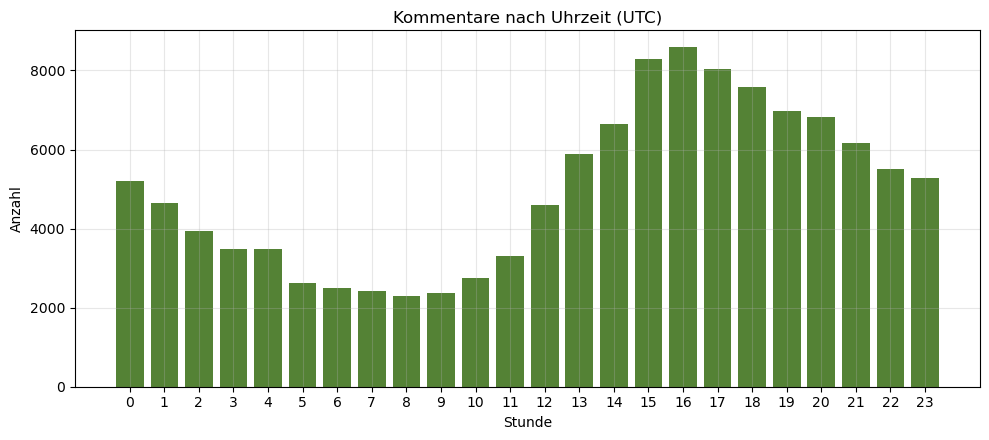

In [17]:
# Stunden-des-Tages-Muster (falls Zeit vorhanden)
if time_col and df["created_dt"].notna().any():
    hours = df["created_dt"].dt.hour.value_counts().sort_index()
    fig, ax = plt.subplots()
    ax.bar(hours.index, hours.values, color="#548235")
    ax.set_title("Kommentare nach Uhrzeit (UTC)")
    ax.set_xlabel("Stunde"); ax.set_ylabel("Anzahl")
    ax.set_xticks(range(0,24))
    plt.tight_layout(); plt.show()

## 8. Nutzer & Bots

Wer kommentiert am meisten? Bots wie `AutoModerator` und gelöschte Accounts
verzerren die Diskurs-Analyse und sollten fürs Labeling ggf. raus.

In [18]:
if "user" in df.columns:
    user_counts = df["user"].value_counts()
    print("Top 15 aktivste Accounts:")
    print(user_counts.head(15))

    # Bot/deleted-Anteil
    botlike = df["user"].astype(str).str.lower().isin(
        ["automoderator", "[deleted]", "[removed]"])
    print(f"\nBot/gelöscht-artige Kommentare: {botlike.sum():,} "
          f"({botlike.mean()*100:.1f}%)")

Top 15 aktivste Accounts:
user
[deleted]               11023
No_Amoeba6994             259
changemyview-ModTeam      254
MarkRclim                 211
etzel1200                 200
Glavurdan                 184
Inevitable_Price7841      183
CathiGray                 162
GrowFreeFood              159
TheOldOnesAre             156
Various_Succotash_79      151
M795                      133
AutoModerator             113
Temporal_Somnium          108
Erufu_Wizardo             108
Name: count, dtype: int64

Bot/gelöscht-artige Kommentare: 11,136 (9.3%)


Nutzer mit genau 1 Kommentar: 29,138 (64.1% aller Nutzer)
Nutzer mit >50 Kommentaren:   65


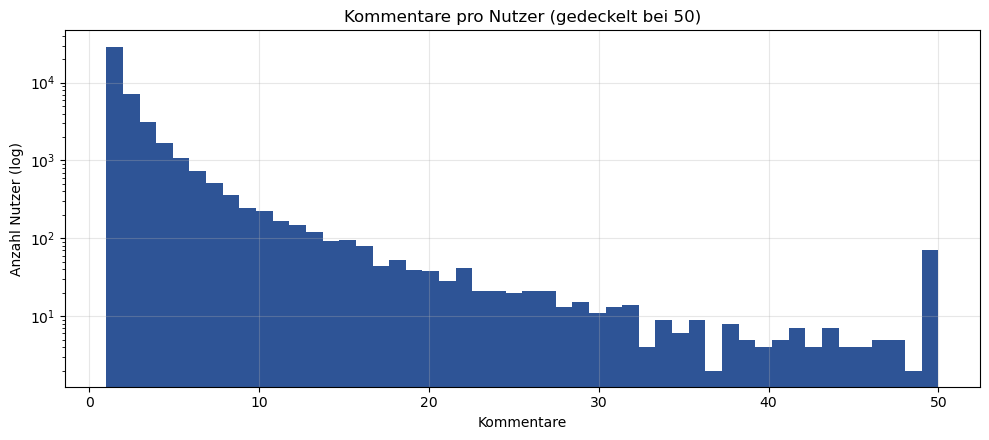

In [19]:
# Verteilung: wie viele Nutzer sind Vielschreiber vs. Einmal-Kommentierer?
if "user" in df.columns:
    posts_per_user = df["user"].value_counts()
    once = (posts_per_user == 1).sum()
    print(f"Nutzer mit genau 1 Kommentar: {once:,} "
          f"({once/len(posts_per_user)*100:.1f}% aller Nutzer)")
    print(f"Nutzer mit >50 Kommentaren:   {(posts_per_user>50).sum():,}")

    fig, ax = plt.subplots()
    ax.hist(posts_per_user.clip(upper=50), bins=50, color="#2E5496")
    ax.set_yscale("log")
    ax.set_title("Kommentare pro Nutzer (gedeckelt bei 50)")
    ax.set_xlabel("Kommentare"); ax.set_ylabel("Anzahl Nutzer (log)")
    plt.tight_layout(); plt.show()

## 9. Kompakte Zusammenfassung

Die wichtigsten Kennzahlen gebündelt – gut zum Kopieren in Meeting-Notizen.

In [20]:
print("="*55)
print("DATENSATZ-ZUSAMMENFASSUNG")
print("="*55)
print(f"Kommentare gesamt      : {len(df):,}")
print(f"Threads                : {df['thread_id'].nunique():,}")
print(f"Ø Kommentare/Thread    : {len(df)/df['thread_id'].nunique():.1f}")
if "subreddit" in df: print(f"Subreddits             : {df['subreddit'].nunique()}")
if "user" in df:      print(f"Eindeutige Nutzer      : {df['user'].nunique():,}")
print(f"Ø Wörter/Kommentar     : {df['n_words'].mean():.1f} (Median {df['n_words'].median():.0f})")
print(f"Kurz (<15 Wörter)      : {(df['n_words']<15).mean()*100:.1f}%")
if "depth" in df:     print(f"Top-Level (depth=0)    : {(df['depth']==0).mean()*100:.1f}%")
resolvable = df.apply(parent_status, axis=1).eq("parent_im_datensatz").sum()
print(f"Mit Eltern-Text möglich: {resolvable/len(df)*100:.1f}%")
if "user" in df:
    botlike = df['user'].astype(str).str.lower().isin(['automoderator','[deleted]','[removed]'])
    print(f"Bot/gelöscht           : {botlike.mean()*100:.1f}%")
print("="*55)

DATENSATZ-ZUSAMMENFASSUNG
Kommentare gesamt      : 119,405
Threads                : 988
Ø Kommentare/Thread    : 120.9
Subreddits             : 9
Eindeutige Nutzer      : 45,482
Ø Wörter/Kommentar     : 36.2 (Median 19)
Kurz (<15 Wörter)      : 41.9%
Top-Level (depth=0)    : 31.5%
Mit Eltern-Text möglich: 68.5%
Bot/gelöscht           : 9.3%


---

*Nächste Schritte:* Für das Labeling relevant sind vor allem die
**Textlängen** (Abschnitt 4 – wie viele sehr kurze Kommentare) und die
**Parent-Verfügbarkeit** (Abschnitt 5 – wie viele Kommentare können
responsiveness/agreement bekommen). Beides fließt in die Interpretation der
ABSTAIN-Raten ein.
